In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print(
    "VRAM:",
    round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
    "GB"
)

PyTorch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-80GB
VRAM: 79.25 GB


In [ ]:
!pip install -q \
  "transformers==4.47.1" \
  "accelerate==1.2.1" \
  sentencepiece \
  einops \
  timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 111.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.4/336.4 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 124.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
import torch
import transformers
import huggingface_hub

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("HF Hub:", huggingface_hub.__version__)
print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.11.0+cu128
Transformers: 4.47.1
HF Hub: 0.36.2
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_id = "zai-org/cogagent-9b-20241220"

print("Loading tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(
    model_id,
    trust_remote_code=True
)

print("Loading CogAgent BF16 on A100...")

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    device_map="cuda"
).eval()

print("CogAgent BF16 loaded!")

Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenization_chatglm.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/zai-org/cogagent-9b-20241220:
- tokenization_chatglm.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

model-00005-of-00006.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00006-of-00006.safetensors:   0%|          | 0.00/3.12G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

CogAgent BF16 loaded!


In [ ]:
from PIL import Image
import torch

image_path = "/content/app_1.png"
image = Image.open(image_path).convert("RGB")

task = "Turn off screen recording permission for Microsoft Teams."

query = (
    f"Task: {task}\n"
    "History steps: \n"
    "(Platform: Mac)\n"
    "(Answer in Action-Operation-Sensitive format.)"
)

print(query)

inputs = tokenizer.apply_chat_template(
    [{
        "role": "user",
        "image": image,
        "content": query
    }],
    add_generation_prompt=True,
    tokenize=True,
    return_tensors="pt",
    return_dict=True,
).to(model.device)

print("Generating...")

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=True,
        top_k=1
    )

new_tokens = outputs[:, inputs["input_ids"].shape[1]:]

response = tokenizer.decode(
    new_tokens[0],
    skip_special_tokens=True
)

print("\n========== COGAGENT RESPONSE ==========\n")
print(response)

Task: Turn off screen recording permission for Microsoft Teams.
History steps: 
(Platform: Mac)
(Answer in Action-Operation-Sensitive format.)
Generating...

========== COGAGENT RESPONSE ==========

Action: The task of 'Turn off screen recording permission for Microsoft Teams' has been completed, and the execution has ended.
Grounded Operation: END()
<<END>>


In [ ]:
task = """Turn off screen recording permission for Microsoft Teams.

First inspect the Microsoft Teams permission toggle in the screenshot.
Determine whether the toggle is currently ON or OFF.

- If the Microsoft Teams toggle is ON, click the toggle to turn it OFF.
- If the Microsoft Teams toggle is already OFF, end the task.
"""

query = (
    f"Task: {task}\n"
    "History steps: \n"
    "(Platform: Mac)\n"
    "(Answer in Status-Action-Operation format.)"
)

print("QUERY:\n")
print(query)

inputs = tokenizer.apply_chat_template(
    [{
        "role": "user",
        "image": image,
        "content": query
    }],
    add_generation_prompt=True,
    tokenize=True,
    return_tensors="pt",
    return_dict=True,
).to(model.device)

print("\nGenerating...")

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=True,
        top_k=1
    )

new_tokens = outputs[:, inputs["input_ids"].shape[1]:]

response = tokenizer.decode(
    new_tokens[0],
    skip_special_tokens=True
)

print("\n========== COGAGENT RESPONSE ==========\n")
print(response)

QUERY:

Task: Turn off screen recording permission for Microsoft Teams.

First inspect the Microsoft Teams permission toggle in the screenshot.
Determine whether the toggle is currently ON or OFF.

- If the Microsoft Teams toggle is ON, click the toggle to turn it OFF.
- If the Microsoft Teams toggle is already OFF, end the task.

History steps: 
(Platform: Mac)
(Answer in Status-Action-Operation format.)

Generating...

========== COGAGENT RESPONSE ==========

Status: The Microsoft Teams toggle is currently on, indicating that screen recording permission is enabled for Microsoft Teams.
Action: Click the toggle switch next to Microsoft Teams to turn off the screen recording permission.
Grounded Operation: CLICK(box=[[857,367,908,397]], element_info='[AXGroup]')


In [ ]:
import re
import json

def parse_cogagent_response(response):
    result = {
        "status": None,
        "action": None,
        "operation": None,
        "box": None,
        "element_info": None
    }

    # Status
    status_match = re.search(
        r"Status:\s*(.*?)(?=\s*Action:|$)",
        response,
        re.DOTALL
    )
    if status_match:
        result["status"] = status_match.group(1).strip()

    # Action
    action_match = re.search(
        r"Action:\s*(.*?)(?=\s*Grounded Operation:|$)",
        response,
        re.DOTALL
    )
    if action_match:
        result["action"] = action_match.group(1).strip()

    # Grounded Operation
    operation_match = re.search(
        r"Grounded Operation:\s*([A-Z]+)",
        response
    )
    if operation_match:
        result["operation"] = operation_match.group(1)

    # Bounding box
    box_match = re.search(
        r"box=\[\[(\d+),(\d+),(\d+),(\d+)\]\]",
        response
    )
    if box_match:
        result["box"] = [
            int(box_match.group(1)),
            int(box_match.group(2)),
            int(box_match.group(3)),
            int(box_match.group(4))
        ]

    # Element info
    element_match = re.search(
        r"element_info='([^']*)'",
        response
    )
    if element_match:
        result["element_info"] = element_match.group(1)

    return result


cogagent_json = parse_cogagent_response(response)

print(json.dumps(
    cogagent_json,
    indent=2,
    ensure_ascii=False
))


{
  "status": "The Microsoft Teams toggle is currently on, indicating that screen recording permission is enabled for Microsoft Teams.",
  "action": "Click the toggle switch next to Microsoft Teams to turn off the screen recording permission.",
  "operation": "CLICK",
  "box": [
    857,
    367,
    908,
    397
  ],
  "element_info": "[AXGroup]"
}


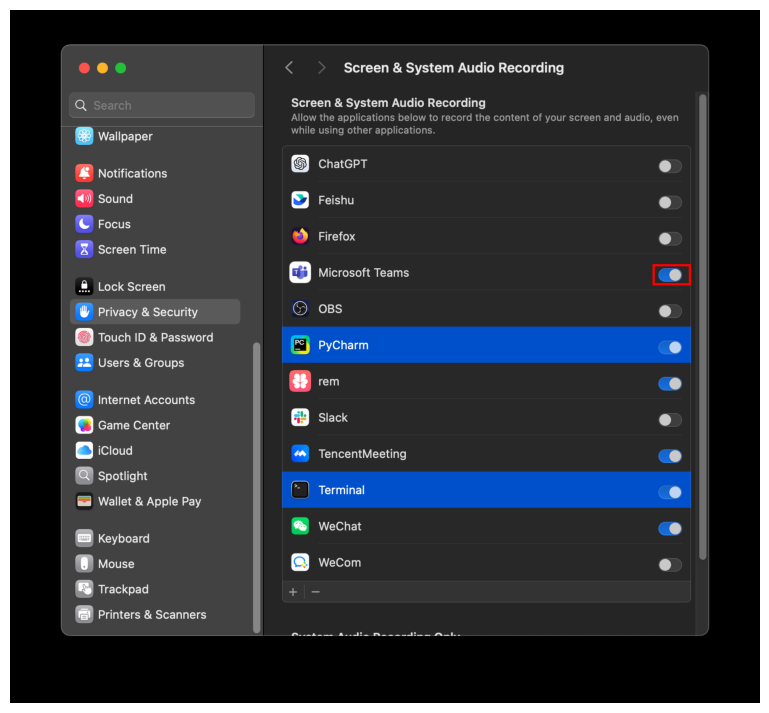

Pixel box: [1417, 561, 1501, 607]


In [ ]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

image_path = "/content/app_1.png"
image = Image.open(image_path).convert("RGB")

# CogAgent box coordinates are normalized to 0–1000
box = cogagent_json["box"]

x1 = int(box[0] / 1000 * image.width)
y1 = int(box[1] / 1000 * image.height)
x2 = int(box[2] / 1000 * image.width)
y2 = int(box[3] / 1000 * image.height)

draw = ImageDraw.Draw(image)
draw.rectangle([x1, y1, x2, y2], outline="red", width=5)

plt.figure(figsize=(14, 9))
plt.imshow(image)
plt.axis("off")
plt.show()

print("Pixel box:", [x1, y1, x2, y2])

In [ ]:
import json
from datetime import datetime, timezone

# CogAgent'ın 0-1000 koordinat sistemindeki bbox'ı
box = cogagent_json["box"]

# Merkez nokta — Unity/Python tarafında click target olarak da kullanılabilir
center_x = int((box[0] + box[2]) / 2)
center_y = int((box[1] + box[3]) / 2)

neurotwin_command = {
    "source": "CogAgent",
    "type": "ui_action",

    "state": {
        "description": cogagent_json["status"]
    },

    "decision": {
        "action": cogagent_json["action"]
    },

    "command": {
        "operation": cogagent_json["operation"].lower(),
        "target": {
            "element": cogagent_json["element_info"],
            "bbox_1000": box,
            "center_1000": [center_x, center_y]
        }
    },

    "timestamp": datetime.now(timezone.utc).isoformat()
}

print(json.dumps(
    neurotwin_command,
    indent=2,
    ensure_ascii=False
))

{
  "source": "CogAgent",
  "type": "ui_action",
  "state": {
    "description": "The Microsoft Teams toggle is currently on, indicating that screen recording permission is enabled for Microsoft Teams."
  },
  "decision": {
    "action": "Click the toggle switch next to Microsoft Teams to turn off the screen recording permission."
  },
  "command": {
    "operation": "click",
    "target": {
      "element": "[AXGroup]",
      "bbox_1000": [
        857,
        367,
        908,
        397
      ],
      "center_1000": [
        882,
        382
      ]
    }
  },
  "timestamp": "2026-08-13T22:39:51.151600+00:00"
}


In [ ]:
output_path = "/content/neurotwin_command.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(
        neurotwin_command,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Saved:", output_path)

Saved: /content/neurotwin_command.json


In [ ]:
from PIL import Image, ImageDraw

image = Image.open("/content/app_1.png").convert("RGB")

box = [857, 367, 908, 397]

x1 = int(box[0] / 1000 * image.width)
y1 = int(box[1] / 1000 * image.height)
x2 = int(box[2] / 1000 * image.width)
y2 = int(box[3] / 1000 * image.height)

draw = ImageDraw.Draw(image)
draw.rectangle([x1, y1, x2, y2], outline="red", width=5)

image.save("/content/grounded_app_1.png")

print("Saved: /content/grounded_app_1.png")

Saved: /content/grounded_app_1.png


In [ ]:
import torch
import transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

PyTorch: 2.11.0+cu128
Transformers: 5.13.1
CUDA: True
GPU: NVIDIA A100-SXM4-80GB
VRAM: 79.25 GB


In [ ]:
import torch
import transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Transformers: 4.47.1
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_id = "zai-org/cogagent-9b-20241220"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    model_id,
    trust_remote_code=True
)

print("Loading CogAgent...")
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    trust_remote_code=True,
    device_map="auto"
).eval()

print("CogAgent loaded!")
print("GPU:", torch.cuda.get_device_name(0))

Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenization_chatglm.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/zai-org/cogagent-9b-20241220:
- tokenization_chatglm.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

model-00005-of-00006.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00006-of-00006.safetensors:   0%|          | 0.00/3.12G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

CogAgent loaded!
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

drive_model_dir = "/content/drive/MyDrive/NeuroTwin/models/cogagent-9b-20241220"
os.makedirs(drive_model_dir, exist_ok=True)

print(drive_model_dir)

/content/drive/MyDrive/NeuroTwin/models/cogagent-9b-20241220


In [ ]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="zai-org/cogagent-9b-20241220",
    local_dir=drive_model_dir
)

print("CogAgent permanently saved to Drive!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

.gitattributes: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

README_zh.md: 0.00B [00:00, ?B/s]

LICENSE: 0.00B [00:00, ?B/s]

CogAgent permanently saved to Drive!


In [ ]:
!pip install -q "transformers==4.47.1" "accelerate==1.2.1" sentencepiece einops timm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_id = "/content/drive/MyDrive/NeuroTwin/models/cogagent-9b-20241220"

print("Loading tokenizer from Drive...")
tokenizer = AutoTokenizer.from_pretrained(
    model_id,
    trust_remote_code=True
)

print("Loading CogAgent from Drive...")
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    device_map="cuda"
).eval()

print("CogAgent loaded!")
print("GPU:", torch.cuda.get_device_name(0))

Loading tokenizer from Drive...
Loading CogAgent from Drive...


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

CogAgent loaded!
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
from PIL import Image
import torch

image_path = "/content/learner_01_correct.png"
image = Image.open(image_path).convert("RGB")

query = """
Analyze this learner-interaction screenshot.

Based only on visually observable information in the screenshot, answer:

1. What is the learner currently interacting with?
2. Is there visible evidence of an incorrect interaction?
3. What observable action appears to have occurred?

Do not infer cognitive load, stress, confusion, attention, emotion, or any other internal cognitive state.

Answer in this format:

Interacting with:
Incorrect interaction evidence:
Observable action:
"""

inputs = tokenizer.apply_chat_template(
    [{
        "role": "user",
        "image": image,
        "content": query
    }],
    add_generation_prompt=True,
    tokenize=True,
    return_tensors="pt",
    return_dict=True,
).to(model.device)

print("Generating...")

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=False
    )

new_tokens = outputs[:, inputs["input_ids"].shape[1]:]

response1 = tokenizer.decode(
    new_tokens[0],
    skip_special_tokens=True
)

print("\n=== SCREENSHOT 1 RESPONSE ===\n")
print(response1)

Generating...


/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(



=== SCREENSHOT 1 RESPONSE ===

Interacting with: The red sphere in the center of the screen.
Incorrect interaction evidence: None
Observable action: The learner has selected the red sphere, which is indicated by the green glow around it.


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'drive', '.ipynb_checkpoints', 'learner_01_correct.png', 'learner_02_incorrect.png', 'sample_data']


In [ ]:
import os

image_path = "/content/learner_02_incorrect.png"

print("Exists:", os.path.exists(image_path))
print("Path:", image_path)

Exists: True
Path: /content/learner_02_incorrect.png


In [ ]:
image_path = "/content/learner_02_incorrect.png"
image = Image.open(image_path).convert("RGB")

inputs = tokenizer.apply_chat_template(
    [{
        "role": "user",
        "image": image,
        "content": query
    }],
    add_generation_prompt=True,
    tokenize=True,
    return_tensors="pt",
    return_dict=True,
).to(model.device)

print("Generating...")

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=False
    )

new_tokens = outputs[:, inputs["input_ids"].shape[1]:]

response2 = tokenizer.decode(
    new_tokens[0],
    skip_special_tokens=True
)

print("\n=== SCREENSHOT 2 RESPONSE ===\n")
print(response2)

Generating...

=== SCREENSHOT 2 RESPONSE ===

Interacting with: The blue cube on the table
Incorrect interaction evidence: The red sphere was not selected, and the 'Incorrect!' message is displayed.
Observable action: The learner has selected the blue cube instead of the red sphere.


In [ ]:
image_path = "/content/learner_03_repeated_error.png"
image = Image.open(image_path).convert("RGB")

inputs = tokenizer.apply_chat_template(
    [{
        "role": "user",
        "image": image,
        "content": query
    }],
    add_generation_prompt=True,
    tokenize=True,
    return_tensors="pt",
    return_dict=True,
).to(model.device)

print("Generating...")

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=False
    )

new_tokens = outputs[:, inputs["input_ids"].shape[1]:]

response3 = tokenizer.decode(
    new_tokens[0],
    skip_special_tokens=True
)

print("\n=== SCREENSHOT 3 RESPONSE ===\n")
print(response3)

Generating...

=== SCREENSHOT 3 RESPONSE ===

Interacting with: The blue cube with a red outline.
Incorrect interaction evidence: The red 'X' button on the left side of the 'Incorrect again!' message indicates a previous incorrect selection.
Observable action: The learner has selected the blue cube with a red outline, which is not the red sphere as instructed.


In [ ]:
image_path = "/content/learner_04_help.png"
image = Image.open(image_path).convert("RGB")

inputs = tokenizer.apply_chat_template(
    [{
        "role": "user",
        "image": image,
        "content": query
    }],
    add_generation_prompt=True,
    tokenize=True,
    return_tensors="pt",
    return_dict=True,
).to(model.device)

print("Generating...")

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=False
    )

new_tokens = outputs[:, inputs["input_ids"].shape[1]:]

response4 = tokenizer.decode(
    new_tokens[0],
    skip_special_tokens=True
)

print("\n=== SCREENSHOT 4 RESPONSE ===\n")
print(response4)

Generating...

=== SCREENSHOT 4 RESPONSE ===

Interacting with: The red sphere in the center of the pop-up window.
Incorrect interaction evidence: The blue button labeled 'Got it!' indicates that the learner has understood the instruction, suggesting that the task of selecting the red sphere is being completed.
Observable action: The learner has clicked on the red sphere in the center of the pop-up window, which is likely an element intended to close the pop-up or confirm understanding.


In [ ]:
image_path = "/content/learner_05_complete.png"
image = Image.open(image_path).convert("RGB")

inputs = tokenizer.apply_chat_template(
    [{
        "role": "user",
        "image": image,
        "content": query
    }],
    add_generation_prompt=True,
    tokenize=True,
    return_tensors="pt",
    return_dict=True,
).to(model.device)

print("Generating...")

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=False
    )

new_tokens = outputs[:, inputs["input_ids"].shape[1]:]

response5 = tokenizer.decode(
    new_tokens[0],
    skip_special_tokens=True
)

print("\n=== SCREENSHOT 5 RESPONSE ===\n")
print(response5)

Generating...

=== SCREENSHOT 5 RESPONSE ===

Interacting with: The red sphere in the center of the screen.
Incorrect interaction evidence: None
Observable action: The learner has selected the red sphere, which is highlighted with a green circle, and the task is marked as completed.


In [ ]:
import json

step3_results = [
    {
        "screenshot": "learner_01_correct.png",
        "scenario": "Correct interaction",
        "cogagent_response": response1
    },
    {
        "screenshot": "learner_02_incorrect.png",
        "scenario": "Incorrect interaction",
        "cogagent_response": response2
    },
    {
        "screenshot": "learner_03_repeated_error.png",
        "scenario": "Repeated incorrect interaction",
        "cogagent_response": response3
    },
    {
        "screenshot": "learner_04_help.png",
        "scenario": "Help-seeking",
        "cogagent_response": response4
    },
    {
        "screenshot": "learner_05_complete.png",
        "scenario": "Activity completion",
        "cogagent_response": response5
    }
]

output_path = "/content/cogagent_step3_results.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(step3_results, f, indent=2, ensure_ascii=False)

print("Saved:", output_path)

Saved: /content/cogagent_step3_results.json


In [ ]:
for i, result in enumerate(step3_results, 1):
    print(f"\n========== EXAMPLE {i} ==========")
    print("Scenario:", result["scenario"])
    print(result["cogagent_response"])


========== EXAMPLE 1 ==========
Scenario: Correct interaction
Interacting with: The red sphere in the center of the screen.
Incorrect interaction evidence: None
Observable action: The learner has selected the red sphere, which is indicated by the green glow around it.

========== EXAMPLE 2 ==========
Scenario: Incorrect interaction
Interacting with: The blue cube on the table
Incorrect interaction evidence: The red sphere was not selected, and the 'Incorrect!' message is displayed.
Observable action: The learner has selected the blue cube instead of the red sphere.

========== EXAMPLE 3 ==========
Scenario: Repeated incorrect interaction
Interacting with: The blue cube with a red outline.
Incorrect interaction evidence: The red 'X' button on the left side of the 'Incorrect again!' message indicates a previous incorrect selection.
Observable action: The learner has selected the blue cube with a red outline, which is not the red sphere as instructed.

========== EXAMPLE 4 ==========
Sce

In [ ]:
import json

step3_results = [
    {
        "screenshot": "learner_01_correct.png",
        "scenario": "Correct interaction",
        "cogagent_response": """Interacting with: The red sphere in the center of the screen.
Incorrect interaction evidence: None
Observable action: The learner has selected the red sphere, which is indicated by the green glow around it."""
    },
    {
        "screenshot": "learner_02_incorrect.png",
        "scenario": "Incorrect interaction",
        "cogagent_response": """Interacting with: The blue cube on the table
Incorrect interaction evidence: The red sphere was not selected, and the 'Incorrect!' message is displayed.
Observable action: The learner has selected the blue cube instead of the red sphere."""
    },
    {
        "screenshot": "learner_03_repeated_error.png",
        "scenario": "Repeated incorrect interaction",
        "cogagent_response": """Interacting with: The blue cube with a red outline.
Incorrect interaction evidence: The red 'X' button on the left side of the 'Incorrect again!' message indicates a previous incorrect selection.
Observable action: The learner has selected the blue cube with a red outline, which is not the red sphere as instructed."""
    },
    {
        "screenshot": "learner_04_help.png",
        "scenario": "Help-seeking",
        "cogagent_response": """Interacting with: The red sphere in the center of the pop-up window.
Incorrect interaction evidence: The blue button labeled 'Got it!' indicates that the learner has understood the instruction, suggesting that the task of selecting the red sphere is being completed.
Observable action: The learner has clicked on the red sphere in the center of the pop-up window, which is likely an element intended to close the pop-up or confirm understanding."""
    },
    {
        "screenshot": "learner_05_complete.png",
        "scenario": "Activity completion",
        "cogagent_response": """Interacting with: The red sphere in the center of the screen.
Incorrect interaction evidence: None
Observable action: The learner has selected the red sphere, which is highlighted with a green circle, and the task is marked as completed."""
    }
]

output_path = "/content/cogagent_step3_results.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(step3_results, f, indent=2, ensure_ascii=False)

print("Saved:", output_path)

Saved: /content/cogagent_step3_results.json
